# Practical Lab 1 — Streaming Data for Predictive Maintenance with Linear Regression-Based Alerts

Juan Camilo Chirivi - ID 9115141

The workflow includes:

- Historical CSV loading and cleaning
- Neon PostgreSQL storage and retrieval
- Eight independent univariate Linear Regression models
- Residual analysis
- Data-driven MinC and MaxC thresholds
- Persistence threshold `T`
- Synthetic testing data generated from training data retrieved from Neon
- Standardization using `StandardScaler`
- Controlled Alert and Error scenarios
- Event detection and logging
- Time-based streaming into Neon PostgreSQL
- Interactive analysis plots
- Final regression visualization with Alert/Error markers and durations

Each Axis is modeled independently using:

**X = elapsed time in seconds**

**y = current measurement for one Axis**


## Imports and Project Setup

In [1]:
import sys
import time
from pathlib import Path

# Data analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# SQL
from sqlalchemy import text

# Project paths
cwd = Path.cwd()
project_root = cwd.parent if cwd.name.lower() == "notebooks" else cwd

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

training_file = project_root / "data" / "training" / "RMBR4-2_export_test.csv"
testing_folder = project_root / "data" / "testing"
results_folder = project_root / "results"

testing_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)

axes = [f"Axis #{i}" for i in range(1, 9)]

print("Project root:", project_root)
print("Training file:", training_file)


Project root: d:\Conestoga\Foundations ML Frameworks\Streming + Linear (practical lab 1)\Streaming-Data_W_Linear-Regression_Practical-Lab1
Training file: d:\Conestoga\Foundations ML Frameworks\Streming + Linear (practical lab 1)\Streaming-Data_W_Linear-Regression_Practical-Lab1\data\training\RMBR4-2_export_test.csv


## Load and Clean Historical Data

In [2]:
# Load original historical CSV
df = pd.read_csv(training_file)

print("Original shape:", df.shape)
display(df.head())

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing"))

# Axis #9 through Axis #14 contain only missing values and
# are not required by this assignment.
selected_columns = ["Time"] + axes
df_selected = df[selected_columns].copy()

print("Selected shape:", df_selected.shape)
display(df_selected.describe())


Original shape: (39672, 16)


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z



Missing values:


,Missing
Trait,0
Axis #1,0
Axis #2,0
Axis #3,0
Axis #4,0
Axis #5,0
Axis #6,0
Axis #7,0
Axis #8,0
Axis #9,39672


Selected shape: (39672, 9)


,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8
count,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000
mean,0.725743,3.613374,2.710336,0.620222,0.954521,0.599427,0.870145,0.102214
std,2.162120,6.879962,5.111901,1.574897,2.100186,1.815498,2.166811,0.423075
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.312710,4.217190,4.586190,0.516190,0.800090,0.361330,0.310030,0.078480
max,23.609300,51.713230,41.855560,15.666300,20.750760,20.931420,8.108480,5.905640


### Time preprocessing

The original `Time` column contains timestamps. Linear Regression requires a numeric independent variable, so the timestamps are converted to elapsed seconds from the first observation.


In [3]:
# Convert timestamp text into datetime
df_selected["Time_datetime"] = pd.to_datetime(
    df_selected["Time"],
    utc=True
)

# Convert time into elapsed seconds
df_selected["Time_seconds"] = (
    df_selected["Time_datetime"]
    - df_selected["Time_datetime"].iloc[0]
).dt.total_seconds()

display(
    df_selected[
        ["Time", "Time_seconds"] + axes
    ].head()
)

print(
    "Training duration:",
    round(df_selected["Time_seconds"].iloc[-1], 2),
    "seconds"
)


,Time,Time_seconds,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8
0,2022-10-17T12:18:23.660Z,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17T12:18:25.472Z,1.812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17T12:18:27.348Z,3.688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17T12:18:29.222Z,5.562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17T12:18:31.117Z,7.457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Training duration: 80794.97 seconds


## Current Visualization

In [4]:
axis_raw_dropdown = widgets.Dropdown(
    options=axes,
    value="Axis #1",
    description="Axis:"
)

raw_output = widgets.Output()

def plot_raw_axis(axis):
    with raw_output:
        clear_output(wait=True)

        plt.figure(figsize=(12, 4))
        plt.plot(
            df_selected["Time_seconds"],
            df_selected[axis]
        )
        plt.title(f"{axis} Current Over Time")
        plt.xlabel("Elapsed Time (seconds)")
        plt.ylabel("Current")
        plt.grid(True)
        plt.show()

def update_raw_plot(change):
    plot_raw_axis(change["new"])

axis_raw_dropdown.observe(update_raw_plot, names="value")

display(axis_raw_dropdown, raw_output)
plot_raw_axis("Axis #1")


Dropdown(description='Axis:', options=('Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis…

Output()

## 4. Neon PostgreSQL Integration

The historical dataset is first stored in Neon PostgreSQL and then queried back into the application. The regression models are trained from the data retrieved from the relational database.


In [5]:
from src.database import get_database_engine

# Create database engine
engine = get_database_engine()

# Verify connection
with engine.connect() as connection:
    result = connection.execute(text("SELECT 1"))

print("Database connection successful.")
print("Test result:", result.scalar())


Database connection successful.
Test result: 1


In [ ]:
# Prepare database-friendly historical dataset
training_db_df = df_selected[
    ["Time", "Time_seconds"] + axes
].copy()

training_db_df.columns = [
    "time_original",
    "time_seconds",
    "axis_1",
    "axis_2",
    "axis_3",
    "axis_4",
    "axis_5",
    "axis_6",
    "axis_7",
    "axis_8"
]

print("Rows to upload:", len(training_db_df))

training_db_df.to_sql(
    name="robot_training_data",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=1000
)

print("Historical training data uploaded to Neon.")


Rows to upload: 39672
Historical training data uploaded to Neon.


In [ ]:
# Query historical training data back from Neon
query = '''
SELECT *
FROM robot_training_data
ORDER BY time_seconds
'''

training_from_db = pd.read_sql(
    query,
    con=engine
)

print("Historical data loaded from Neon.")
print("Shape:", training_from_db.shape)
display(training_from_db.head())

rename_from_db = {
    "time_original": "Time",
    "time_seconds": "Time_seconds",
    **{f"axis_{i}": f"Axis #{i}" for i in range(1, 9)}
}

df_selected = training_from_db.rename(
    columns=rename_from_db
)[["Time", "Time_seconds"] + axes].copy()

print("Training DataFrame ready from Neon:", df_selected.shape)


Historical data loaded from Neon.
Shape: (39672, 10)


,time_original,time_seconds,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,2022-10-17T12:18:23.660Z,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17T12:18:25.472Z,1.812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17T12:18:27.348Z,3.688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17T12:18:29.222Z,5.562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17T12:18:31.117Z,7.457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Training DataFrame ready from Neon: (39672, 10)


## Train Eight Univariate Linear Regression Models

In [ ]:
models = {}
model_results = []

X = df_selected[["Time_seconds"]]

for axis in axes:
    y = df_selected[axis]

    model = LinearRegression()
    model.fit(X, y)

    models[axis] = model

    # Predictions and residuals
    df_selected[f"{axis}_predicted"] = model.predict(X)
    df_selected[f"{axis}_residual"] = (
        df_selected[axis]
        - df_selected[f"{axis}_predicted"]
    )

    model_results.append({
        "Axis": axis,
        "Slope": model.coef_[0],
        "Intercept": model.intercept_,
        "R2": model.score(X, y)
    })

model_summary = pd.DataFrame(model_results)

display(model_summary.round(6))


,Axis,Slope,Intercept,R2
0,Axis #1,-0.000000,0.730542,0.000002
1,Axis #2,0.000002,3.523886,0.000054
2,Axis #3,-0.000001,2.733898,0.000007
3,Axis #4,0.000000,0.604357,0.000033
4,Axis #5,0.000000,0.951103,0.000001
5,Axis #6,0.000000,0.580077,0.000037
6,Axis #7,0.000001,0.847563,0.000035
7,Axis #8,0.000000,0.098748,0.000022


### Regression visualization

The scatter points are the observed current values. The regression line is the model estimate of expected current over time.


In [ ]:
axis_regression_dropdown = widgets.Dropdown(
    options=axes,
    value="Axis #1",
    description="Axis:"
)

regression_output = widgets.Output()

def plot_regression(axis):
    with regression_output:
        clear_output(wait=True)

        plt.figure(figsize=(12, 5))

        plt.scatter(
            df_selected["Time_seconds"],
            df_selected[axis],
            s=5,
            alpha=0.35,
            label="Actual"
        )

        plt.plot(
            df_selected["Time_seconds"],
            df_selected[f"{axis}_predicted"],
            label="Linear Regression"
        )

        plt.title(f"{axis} - Historical Data and Regression")
        plt.xlabel("Elapsed Time (seconds)")
        plt.ylabel("Current")
        plt.legend()
        plt.grid(True)
        plt.show()

def update_regression(change):
    plot_regression(change["new"])

axis_regression_dropdown.observe(update_regression, names="value")

display(axis_regression_dropdown, regression_output)
plot_regression("Axis #1")


Dropdown(description='Axis:', options=('Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis…

Output()

## Residual Analysis and Threshold Discovery

Residual:

**Residual = Actual - Predicted**

Only positive residuals are used because the assignment defines Alert/Error thresholds as current deviation **above** the regression line.

For every Axis:

- **MinC = P95** of positive historical residuals
- **MaxC = P99** of positive historical residuals

Using high percentiles makes MinC sensitive to unusual deviations while MaxC represents more extreme deviations.


In [ ]:
threshold_rows = []
thresholds = {}

for axis in axes:
    residual_column = f"{axis}_residual"

    positive_residuals = df_selected.loc[
        df_selected[residual_column] > 0,
        residual_column
    ]

    min_c = positive_residuals.quantile(0.95)
    max_c = positive_residuals.quantile(0.99)

    thresholds[axis] = {
        "MinC": float(min_c),
        "MaxC": float(max_c)
    }

    threshold_rows.append({
        "Axis": axis,
        "MinC_P95": min_c,
        "MaxC_P99": max_c
    })

thresholds_df = pd.DataFrame(threshold_rows)

display(thresholds_df.round(4))


,Axis,MinC_P95,MaxC_P99
0,Axis #1,11.3438,20.0266
1,Axis #2,24.5676,39.4509
2,Axis #3,19.6594,27.6974
3,Axis #4,7.2060,11.7136
4,Axis #5,8.5170,14.0363
5,Axis #6,9.4692,14.3679
6,Axis #7,7.2327,7.2473
7,Axis #8,3.1362,4.0778


In [ ]:
# Interactive residual distribution
axis_threshold_dropdown = widgets.Dropdown(
    options=axes,
    value="Axis #1",
    description="Axis:"
)

threshold_output = widgets.Output()

def plot_threshold_distribution(axis):
    residual_column = f"{axis}_residual"

    positive_residuals = df_selected.loc[
        df_selected[residual_column] > 0,
        residual_column
    ]

    min_c = thresholds[axis]["MinC"]
    max_c = thresholds[axis]["MaxC"]

    with threshold_output:
        clear_output(wait=True)

        plt.figure(figsize=(10, 4))
        plt.hist(positive_residuals, bins=50, alpha=0.7)

        plt.axvline(
            min_c,
            linestyle="--",
            label=f"MinC P95 = {min_c:.2f}"
        )

        plt.axvline(
            max_c,
            linestyle="--",
            label=f"MaxC P99 = {max_c:.2f}"
        )

        plt.title(f"{axis} - Positive Residual Distribution")
        plt.xlabel("Positive Residual")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True)
        plt.show()

def update_threshold_plot(change):
    plot_threshold_distribution(change["new"])

axis_threshold_dropdown.observe(
    update_threshold_plot,
    names="value"
)

display(axis_threshold_dropdown, threshold_output)
plot_threshold_distribution("Axis #1")


Dropdown(description='Axis:', options=('Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis…

Output()

## Persistence Threshold `T`

An isolated spike should not automatically become a confirmed Alert or Error. Historical exceedance durations are therefore analyzed.

Candidate values of **2, 4, and 6 seconds** are compared.


In [ ]:
def find_sustained_events(
    time_values,
    residual_values,
    threshold,
    max_gap=3.0
):
    '''
    Find continuous periods where residuals remain
    at or above a threshold.
    '''

    events = []
    start_time = None
    previous_time = None

    for current_time, residual in zip(
        time_values,
        residual_values
    ):

        if residual >= threshold:

            if start_time is None:
                start_time = current_time

            elif (
                previous_time is not None
                and current_time - previous_time > max_gap
            ):
                events.append({
                    "Start_Time": start_time,
                    "End_Time": previous_time,
                    "Duration": previous_time - start_time
                })

                start_time = current_time

            previous_time = current_time

        else:
            if start_time is not None:
                events.append({
                    "Start_Time": start_time,
                    "End_Time": previous_time,
                    "Duration": previous_time - start_time
                })

            start_time = None
            previous_time = None

    if start_time is not None:
        events.append({
            "Start_Time": start_time,
            "End_Time": previous_time,
            "Duration": previous_time - start_time
        })

    return events


candidate_times = [2, 4, 6]
time_analysis_results = []

for axis in axes:
    residual_column = f"{axis}_residual"
    min_c = thresholds[axis]["MinC"]

    events = find_sustained_events(
        df_selected["Time_seconds"].values,
        df_selected[residual_column].values,
        min_c
    )

    durations = [
        event["Duration"]
        for event in events
    ]

    result = {
        "Axis": axis,
        "Total_Events": len(events)
    }

    for candidate_t in candidate_times:
        result[f"Events_>=_{candidate_t}s"] = sum(
            duration >= candidate_t
            for duration in durations
        )

    time_analysis_results.append(result)

time_analysis_df = pd.DataFrame(time_analysis_results)

display(time_analysis_df)

T = 4.0
print(f"Selected persistence threshold T = {T} seconds")


,Axis,Total_Events,Events_>=_2s,Events_>=_4s,Events_>=_6s
0,Axis #1,333,0,0,0
1,Axis #2,561,0,0,0
2,Axis #3,575,0,0,0
3,Axis #4,470,0,0,0
4,Axis #5,424,0,0,0
5,Axis #6,405,0,0,0
6,Axis #7,288,3,0,0
7,Axis #8,297,0,0,0


Selected persistence threshold T = 4.0 seconds


### Threshold justification

`MinC` and `MaxC` are derived from the historical residual distribution instead of being fixed arbitrary values.

- `MinC = P95` identifies uncommon positive deviations.
- `MaxC = P99` represents more extreme deviations.
- `T = 4 seconds` is used to filter short spikes observed in the historical data.

In a predictive-maintenance context, this combination reduces the chance that a single temporary spike becomes a confirmed event while preserving sensitivity to sustained abnormal behavior.

`T = 4` is an experimental value for this lab and is not presented as a universal industrial safety limit.


## Standardize Training Data and Generate Synthetic Testing Data

The synthetic data is generated **after the historical training data has been retrieved from Neon**.

`StandardScaler` is fit only on the Neon training data:

- Mean becomes approximately 0.
- Standard deviation becomes approximately 1.

Synthetic standardized records are created by sampling historical standardized patterns and adding a small amount of Gaussian variation. The data is then transformed back to the original current scale.


In [ ]:
# Fit scaler using the historical data retrieved from Neon
scaler = StandardScaler()

training_scaled = scaler.fit_transform(
    df_selected[axes]
)

training_scaled_df = pd.DataFrame(
    training_scaled,
    columns=axes
)

print("Standardized training means:")
display(training_scaled_df.mean().round(3).to_frame("Mean"))

print("Standardized training standard deviations:")
display(training_scaled_df.std(ddof=0).round(3).to_frame("Std"))


Standardized training means:


,Mean
Axis #1,0.0
Axis #2,0.0
Axis #3,-0.0
Axis #4,0.0
Axis #5,-0.0
Axis #6,-0.0
Axis #7,-0.0
Axis #8,0.0


Standardized training standard deviations:


,Std
Axis #1,1.0
Axis #2,1.0
Axis #3,1.0
Axis #4,1.0
Axis #5,1.0
Axis #6,1.0
Axis #7,1.0
Axis #8,1.0


In [ ]:
np.random.seed(42)

number_of_test_records = 100
sampling_interval = 2.0

# Continue timestamps after the historical dataset
last_training_time = df_selected["Time_seconds"].iloc[-1]

test_time_seconds = (
    last_training_time
    + np.arange(
        1,
        number_of_test_records + 1
    ) * sampling_interval
)

# Sample standardized historical patterns
sample_indices = np.random.choice(
    len(training_scaled_df),
    size=number_of_test_records,
    replace=True
)

synthetic_scaled = training_scaled_df.iloc[
    sample_indices
].to_numpy().copy()

# Add small variation in standardized space
synthetic_scaled += np.random.normal(
    loc=0.0,
    scale=0.05,
    size=synthetic_scaled.shape
)

# Convert synthetic standardized values back
# to the original current units
synthetic_values = scaler.inverse_transform(
    synthetic_scaled
)

synthetic_test_df = pd.DataFrame(
    synthetic_values,
    columns=axes
)

# Current values should not become negative
for axis in axes:
    synthetic_test_df[axis] = synthetic_test_df[axis].clip(
        lower=df_selected[axis].min(),
        upper=df_selected[axis].max()
    )

synthetic_test_df.insert(
    0,
    "Time_seconds",
    test_time_seconds
)

display(synthetic_test_df.head())


,Time_seconds,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8
0,80796.968,17.588180,1.226491,9.658412,0.822323,0.705361,0.457207,0.670740,0.113672
1,80798.968,0.000000,0.000000,0.000000,0.000000,0.015803,0.000000,0.285314,0.000000
2,80800.968,0.202107,11.268664,6.232546,0.954385,0.376900,0.900673,0.055600,0.058207
3,80802.968,0.000000,0.000000,0.000000,0.000000,0.101085,0.000000,0.000000,0.000000
4,80804.968,0.078277,0.000000,0.217233,0.000000,0.000000,0.000000,0.000000,0.062269


In [ ]:
# Compare training and synthetic metadata
metadata_comparison = []

for axis in axes:
    metadata_comparison.append({
        "Axis": axis,
        "Training_Mean": df_selected[axis].mean(),
        "Synthetic_Mean": synthetic_test_df[axis].mean(),
        "Training_Std": df_selected[axis].std(),
        "Synthetic_Std": synthetic_test_df[axis].std()
    })

metadata_comparison_df = pd.DataFrame(
    metadata_comparison
)

display(metadata_comparison_df.round(3))


,Axis,Training_Mean,Synthetic_Mean,Training_Std,Synthetic_Std
0,Axis #1,0.726,0.965,2.162,2.553
1,Axis #2,3.613,3.405,6.880,6.110
2,Axis #3,2.710,2.990,5.112,5.107
3,Axis #4,0.620,0.640,1.575,1.397
4,Axis #5,0.955,0.972,2.100,1.984
5,Axis #6,0.599,0.714,1.815,1.771
6,Axis #7,0.870,1.014,2.167,2.263
7,Axis #8,0.102,0.087,0.423,0.336


In [ ]:
# Generate model predictions and residuals
X_test = synthetic_test_df[["Time_seconds"]]

for axis in axes:
    synthetic_test_df[
        f"{axis}_predicted"
    ] = models[axis].predict(X_test)

    synthetic_test_df[
        f"{axis}_residual"
    ] = (
        synthetic_test_df[axis]
        - synthetic_test_df[f"{axis}_predicted"]
    )

synthetic_normal_df = synthetic_test_df.copy()

display(synthetic_test_df.head())


,Time_seconds,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #1_predicted,...,Axis #4_predicted,Axis #4_residual,Axis #5_predicted,Axis #5_residual,Axis #6_predicted,Axis #6_residual,Axis #7_predicted,Axis #7_residual,Axis #8_predicted,Axis #8_residual
0,80796.968,17.588180,1.226491,9.658412,0.822323,0.705361,0.457207,0.670740,0.113672,0.721034,...,0.635787,0.186536,0.957874,-0.252513,0.618411,-0.161205,0.892301,-0.221561,0.105616,0.008056
1,80798.968,0.000000,0.000000,0.000000,0.000000,0.015803,0.000000,0.285314,0.000000,0.721034,...,0.635788,-0.635788,0.957875,-0.942072,0.618412,-0.618412,0.892303,-0.606988,0.105616,-0.105616
2,80800.968,0.202107,11.268664,6.232546,0.954385,0.376900,0.900673,0.055600,0.058207,0.721034,...,0.635789,0.318596,0.957875,-0.580975,0.618413,0.282260,0.892304,-0.836704,0.105616,-0.047409
3,80802.968,0.000000,0.000000,0.000000,0.000000,0.101085,0.000000,0.000000,0.000000,0.721034,...,0.635789,-0.635789,0.957875,-0.856790,0.618414,-0.618414,0.892305,-0.892305,0.105616,-0.105616
4,80804.968,0.078277,0.000000,0.217233,0.000000,0.000000,0.000000,0.000000,0.062269,0.721034,...,0.635790,-0.635790,0.957875,-0.957875,0.618415,-0.618415,0.892306,-0.892306,0.105616,-0.043347


## Inject Controlled Alert and Error Scenarios

Two sustained test anomalies are inserted into `Axis #1`:

- Rows **20–23**: residual between MinC and MaxC → Alert condition
- Rows **60–63**: residual above MaxC → Error condition

With approximately two seconds between readings, four consecutive abnormal readings span about six seconds, which is greater than `T = 4 seconds`.


In [ ]:
test_axis = "Axis #1"

min_c = thresholds[test_axis]["MinC"]
max_c = thresholds[test_axis]["MaxC"]

# Controlled ALERT
alert_residual = (min_c + max_c) / 2
alert_rows = list(range(20, 24))

for row in alert_rows:
    synthetic_test_df.loc[row, test_axis] = (
        synthetic_test_df.loc[
            row,
            f"{test_axis}_predicted"
        ]
        + alert_residual
    )

# Controlled ERROR
error_residual = max_c * 1.20
error_rows = list(range(60, 64))

for row in error_rows:
    synthetic_test_df.loc[row, test_axis] = (
        synthetic_test_df.loc[
            row,
            f"{test_axis}_predicted"
        ]
        + error_residual
    )

# Recalculate Axis #1 residual after injection
synthetic_test_df[
    f"{test_axis}_residual"
] = (
    synthetic_test_df[test_axis]
    - synthetic_test_df[f"{test_axis}_predicted"]
)

print("Controlled anomalies injected.")
print("Alert rows:", alert_rows)
print("Error rows:", error_rows)


Controlled anomalies injected.
Alert rows: [20, 21, 22, 23]
Error rows: [60, 61, 62, 63]


## Detect and Log Sustained Alert/Error Events

In [ ]:
def create_event_log(
    df,
    axis,
    min_c,
    max_c,
    T
):
    '''
    Group consecutive abnormal readings into sustained
    Alert or Error events.

    Only events with duration >= T are logged.
    '''

    residual_column = f"{axis}_residual"

    event_log = []

    event_type = None
    event_start = None
    detection_time = None
    previous_time = None

    for _, row in df.iterrows():

        current_time = row["Time_seconds"]
        residual = row[residual_column]

        if residual >= max_c:
            current_type = "ERROR"

        elif residual >= min_c:
            current_type = "ALERT"

        else:
            current_type = "NORMAL"

        if current_type == "NORMAL":

            if event_type is not None:
                duration = previous_time - event_start

                if duration >= T:
                    event_log.append({
                        "Axis": axis,
                        "Event": event_type,
                        "Start_Time": event_start,
                        "Detection_Time": detection_time,
                        "End_Time": previous_time,
                        "Duration": duration
                    })

            event_type = None
            event_start = None
            detection_time = None

        else:

            if event_type != current_type:

                if event_type is not None:
                    duration = previous_time - event_start

                    if duration >= T:
                        event_log.append({
                            "Axis": axis,
                            "Event": event_type,
                            "Start_Time": event_start,
                            "Detection_Time": detection_time,
                            "End_Time": previous_time,
                            "Duration": duration
                        })

                event_type = current_type
                event_start = current_time
                detection_time = None

            duration = current_time - event_start

            if duration >= T and detection_time is None:
                detection_time = current_time

        previous_time = current_time

    if event_type is not None:
        duration = previous_time - event_start

        if duration >= T:
            event_log.append({
                "Axis": axis,
                "Event": event_type,
                "Start_Time": event_start,
                "Detection_Time": detection_time,
                "End_Time": previous_time,
                "Duration": duration
            })

    return event_log


all_events = []

for axis in axes:
    axis_events = create_event_log(
        synthetic_test_df,
        axis,
        thresholds[axis]["MinC"],
        thresholds[axis]["MaxC"],
        T
    )

    all_events.extend(axis_events)

all_event_log = pd.DataFrame(all_events)

if not all_event_log.empty:
    display(all_event_log)

    event_summary = (
        all_event_log
        .groupby(["Axis", "Event"])
        .size()
        .reset_index(name="Count")
    )

    print("Event summary:")
    display(event_summary)

else:
    print("No sustained events detected.")


,Axis,Event,Start_Time,Detection_Time,End_Time,Duration
0,Axis #1,ALERT,80836.968,80840.968,80842.968,6.0
1,Axis #1,ERROR,80916.968,80920.968,80922.968,6.0


Event summary:


,Axis,Event,Count
0,Axis #1,ALERT,1
1,Axis #1,ERROR,1


## Final Regression Plot with Alert/Error Markers

This plot directly satisfies the assignment requirement to overlay Alert/Error events on the regression visualization and annotate their durations.

`Axis #1` is used because controlled Alert and Error scenarios were intentionally inserted into this Axis.


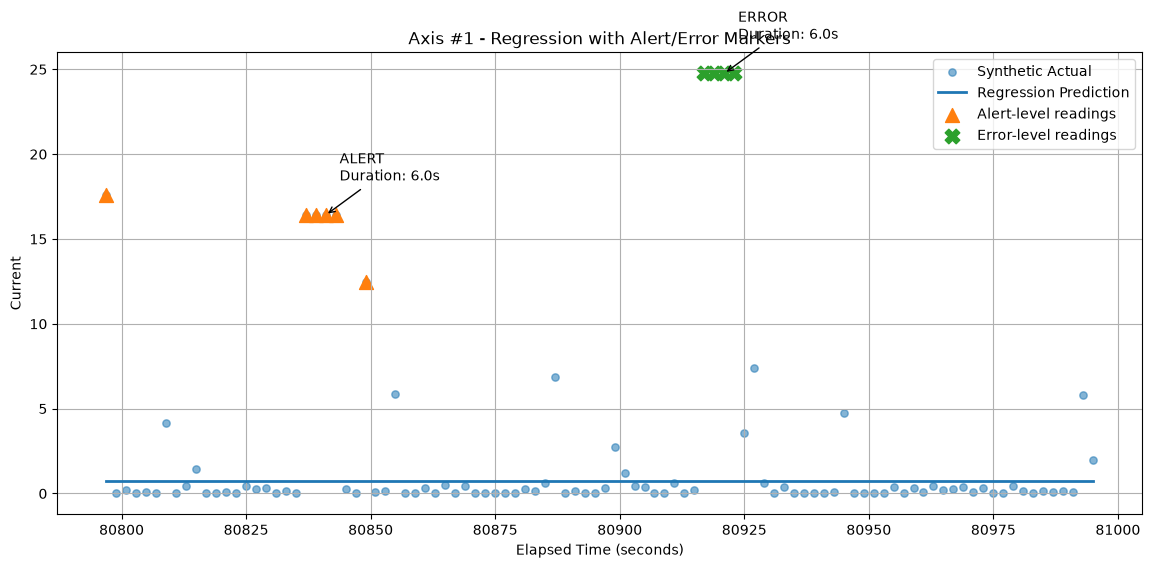

In [ ]:
# Static final plot for GitHub / PDF visibility
axis = "Axis #1"

plt.figure(figsize=(14, 6))

# Synthetic actual values
plt.scatter(
    synthetic_test_df["Time_seconds"],
    synthetic_test_df[axis],
    s=28,
    alpha=0.55,
    label="Synthetic Actual"
)

# Regression prediction
plt.plot(
    synthetic_test_df["Time_seconds"],
    synthetic_test_df[f"{axis}_predicted"],
    linewidth=2,
    label="Regression Prediction"
)

# Alert markers
alert_mask = (
    synthetic_test_df[f"{axis}_residual"]
    >= thresholds[axis]["MinC"]
) & (
    synthetic_test_df[f"{axis}_residual"]
    < thresholds[axis]["MaxC"]
)

plt.scatter(
    synthetic_test_df.loc[alert_mask, "Time_seconds"],
    synthetic_test_df.loc[alert_mask, axis],
    marker="^",
    s=100,
    label="Alert-level readings"
)

# Error markers
error_mask = (
    synthetic_test_df[f"{axis}_residual"]
    >= thresholds[axis]["MaxC"]
)

plt.scatter(
    synthetic_test_df.loc[error_mask, "Time_seconds"],
    synthetic_test_df.loc[error_mask, axis],
    marker="X",
    s=110,
    label="Error-level readings"
)

# Annotate confirmed sustained events with duration
if not all_event_log.empty:

    axis_events = all_event_log[
        all_event_log["Axis"] == axis
    ]

    for _, event in axis_events.iterrows():

        event_time = event["Detection_Time"]

        nearest_index = (
            synthetic_test_df["Time_seconds"]
            - event_time
        ).abs().idxmin()

        event_value = synthetic_test_df.loc[
            nearest_index,
            axis
        ]

        plt.annotate(
            f"{event['Event']}\nDuration: {event['Duration']:.1f}s",
            xy=(event_time, event_value),
            xytext=(10, 25),
            textcoords="offset points",
            arrowprops={"arrowstyle": "->"}
        )

plt.title(
    "Axis #1 - Regression with Alert/Error Markers"
)
plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("Current")
plt.legend()
plt.grid(True)
plt.show()


## Residual Detection Visualization

In [ ]:
axis_detection_dropdown = widgets.Dropdown(
    options=axes,
    value="Axis #1",
    description="Axis:"
)

detection_output = widgets.Output()

def plot_detection_results(axis):

    residual_column = f"{axis}_residual"

    min_c = thresholds[axis]["MinC"]
    max_c = thresholds[axis]["MaxC"]

    with detection_output:
        clear_output(wait=True)

        plt.figure(figsize=(12, 5))

        plt.plot(
            synthetic_test_df["Time_seconds"],
            synthetic_test_df[residual_column],
            marker=".",
            label="Residual"
        )

        plt.axhline(
            min_c,
            linestyle="--",
            label=f"MinC = {min_c:.2f}"
        )

        plt.axhline(
            max_c,
            linestyle="--",
            label=f"MaxC = {max_c:.2f}"
        )

        plt.axhline(
            0,
            linestyle=":",
            label="Residual = 0"
        )

        plt.title(
            f"{axis} - Residual Anomaly Detection"
        )

        plt.xlabel("Elapsed Time (seconds)")
        plt.ylabel("Residual (Actual - Predicted)")
        plt.legend()
        plt.grid(True)
        plt.show()

def update_detection_plot(change):
    plot_detection_results(change["new"])

axis_detection_dropdown.observe(
    update_detection_plot,
    names="value"
)

display(
    axis_detection_dropdown,
    detection_output
)

plot_detection_results("Axis #1")


Dropdown(description='Axis:', options=('Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis…

Output()

## Time-Based Synthetic Streaming into Neon PostgreSQL

A small subset of the synthetic testing dataset is streamed into Neon approximately one row every two seconds. The table is then queried back into the notebook to verify ingestion.


In [ ]:
# Create a database table for streamed synthetic readings
create_stream_table = text('''
CREATE TABLE IF NOT EXISTS robot_streaming_data (
    id BIGSERIAL PRIMARY KEY,
    time_seconds DOUBLE PRECISION NOT NULL,
    axis_1 DOUBLE PRECISION,
    axis_2 DOUBLE PRECISION,
    axis_3 DOUBLE PRECISION,
    axis_4 DOUBLE PRECISION,
    axis_5 DOUBLE PRECISION,
    axis_6 DOUBLE PRECISION,
    axis_7 DOUBLE PRECISION,
    axis_8 DOUBLE PRECISION
)
''')

with engine.begin() as connection:
    connection.execute(create_stream_table)

    # Keep the final notebook run reproducible
    connection.execute(
        text("TRUNCATE TABLE robot_streaming_data RESTART IDENTITY")
    )

print("Streaming table ready.")


Streaming table ready.


In [ ]:
def stream_rows_to_database(
    data,
    engine,
    number_of_records=5,
    interval=2.0
):
    '''
    Simulate a time-based stream from the synthetic testing
    DataFrame into Neon PostgreSQL.
    '''

    records_to_stream = data.head(
        number_of_records
    )

    insert_sql = text('''
        INSERT INTO robot_streaming_data (
            time_seconds,
            axis_1,
            axis_2,
            axis_3,
            axis_4,
            axis_5,
            axis_6,
            axis_7,
            axis_8
        )
        VALUES (
            :time_seconds,
            :axis_1,
            :axis_2,
            :axis_3,
            :axis_4,
            :axis_5,
            :axis_6,
            :axis_7,
            :axis_8
        )
    ''')

    for stream_number, (_, row) in enumerate(
        records_to_stream.iterrows(),
        start=1
    ):

        parameters = {
            "time_seconds": float(row["Time_seconds"]),
            **{
                f"axis_{i}": float(row[f"Axis #{i}"])
                for i in range(1, 9)
            }
        }

        with engine.begin() as connection:
            connection.execute(
                insert_sql,
                parameters
            )

        print(
            f"Streamed record {stream_number}/"
            f"{number_of_records}"
        )

        # Do not wait after the last record
        if stream_number < number_of_records:
            time.sleep(interval)


stream_rows_to_database(
    synthetic_test_df,
    engine,
    number_of_records=5,
    interval=2.0
)


Streamed record 1/5
Streamed record 2/5
Streamed record 3/5
Streamed record 4/5
Streamed record 5/5


In [ ]:
# Query the streamed data back from Neon
streamed_from_db = pd.read_sql(
    '''
    SELECT *
    FROM robot_streaming_data
    ORDER BY id
    ''',
    con=engine
)

print(
    "Streaming records stored in Neon:",
    len(streamed_from_db)
)

display(streamed_from_db)


Streaming records stored in Neon: 5


,id,time_seconds,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,1,80796.968,17.588180,1.226491,9.658412,0.822323,0.705361,0.457207,0.670740,0.113672
1,2,80798.968,0.000000,0.000000,0.000000,0.000000,0.015803,0.000000,0.285314,0.000000
2,3,80800.968,0.202107,11.268664,6.232546,0.954385,0.376900,0.900673,0.055600,0.058207
3,4,80802.968,0.000000,0.000000,0.000000,0.000000,0.101085,0.000000,0.000000,0.000000
4,5,80804.968,0.078277,0.000000,0.217233,0.000000,0.000000,0.000000,0.000000,0.062269


## Save Synthetic Data and Event Log

In [ ]:
synthetic_test_path = (
    testing_folder
    / "synthetic_test_data.csv"
)

event_log_path = (
    results_folder
    / "anomaly_event_log.csv"
)

synthetic_test_df.to_csv(
    synthetic_test_path,
    index=False
)

all_event_log.to_csv(
    event_log_path,
    index=False
)

print("Synthetic testing data saved to:")
print(synthetic_test_path)

print("\nEvent log saved to:")
print(event_log_path)


Synthetic testing data saved to:
d:\Conestoga\Foundations ML Frameworks\Streming + Linear (practical lab 1)\Streaming-Data_W_Linear-Regression_Practical-Lab1\data\testing\synthetic_test_data.csv

Event log saved to:
d:\Conestoga\Foundations ML Frameworks\Streming + Linear (practical lab 1)\Streaming-Data_W_Linear-Regression_Practical-Lab1\results\anomaly_event_log.csv


## Real-Time Prediction and Alert/Error Streaming Simulation

`StreamingSimulator` processes new readings sequentially. For every record and every Axis it:

1. Predicts expected current.
2. Calculates the residual.
3. Applies MinC and MaxC.
4. Tracks persistence duration.
5. Produces `NORMAL`, `ALERT_CANDIDATE`, `ALERT`, `ERROR_CANDIDATE`, or `ERROR`.


In [ ]:
from src.streaming_simulator import StreamingSimulator

ss = StreamingSimulator(
    data=synthetic_test_df,
    models=models,
    thresholds=thresholds,
    T=T,
    interval=2.0
)

print("Streaming simulator ready.")


Streaming simulator ready.


In [ ]:
# Demonstrate controlled Alert section
ss.reset()
ss.current_index = 18

ss.stream(
    number_of_records=8
)



Record 19 | Time: 80832.97
Axis #1 | Actual: 0.119 | Predicted: 0.721 | Residual: -0.603 | Duration: 0.0s | Status: NORMAL
Axis #2 | Actual: 0.000 | Predicted: 3.701 | Residual: -3.701 | Duration: 0.0s | Status: NORMAL
Axis #3 | Actual: 0.162 | Predicted: 2.687 | Residual: -2.525 | Duration: 0.0s | Status: NORMAL
Axis #4 | Actual: 0.000 | Predicted: 0.636 | Residual: -0.636 | Duration: 0.0s | Status: NORMAL
Axis #5 | Actual: 0.000 | Predicted: 0.958 | Residual: -0.958 | Duration: 0.0s | Status: NORMAL
Axis #6 | Actual: 0.000 | Predicted: 0.618 | Residual: -0.618 | Duration: 0.0s | Status: NORMAL
Axis #7 | Actual: 0.000 | Predicted: 0.892 | Residual: -0.892 | Duration: 0.0s | Status: NORMAL
Axis #8 | Actual: 0.000 | Predicted: 0.106 | Residual: -0.106 | Duration: 0.0s | Status: NORMAL

Record 20 | Time: 80834.97
Axis #1 | Actual: 0.049 | Predicted: 0.721 | Residual: -0.672 | Duration: 0.0s | Status: NORMAL
Axis #2 | Actual: 0.612 | Predicted: 3.701 | Residual: -3.089 | Duration: 0.0s |

In [ ]:
# Demonstrate controlled Error section
ss.reset()
ss.current_index = 58

ss.stream(
    number_of_records=8
)



Record 59 | Time: 80912.97
Axis #1 | Actual: 0.000 | Predicted: 0.721 | Residual: -0.721 | Duration: 0.0s | Status: NORMAL
Axis #2 | Actual: 0.000 | Predicted: 3.701 | Residual: -3.701 | Duration: 0.0s | Status: NORMAL
Axis #3 | Actual: 0.127 | Predicted: 2.687 | Residual: -2.560 | Duration: 0.0s | Status: NORMAL
Axis #4 | Actual: 0.000 | Predicted: 0.636 | Residual: -0.636 | Duration: 0.0s | Status: NORMAL
Axis #5 | Actual: 0.000 | Predicted: 0.958 | Residual: -0.958 | Duration: 0.0s | Status: NORMAL
Axis #6 | Actual: 0.000 | Predicted: 0.618 | Residual: -0.618 | Duration: 0.0s | Status: NORMAL
Axis #7 | Actual: 0.086 | Predicted: 0.892 | Residual: -0.806 | Duration: 0.0s | Status: NORMAL
Axis #8 | Actual: 0.003 | Predicted: 0.106 | Residual: -0.103 | Duration: 0.0s | Status: NORMAL

Record 60 | Time: 80914.97
Axis #1 | Actual: 0.194 | Predicted: 0.721 | Residual: -0.527 | Duration: 0.0s | Status: NORMAL
Axis #2 | Actual: 0.000 | Predicted: 3.701 | Residual: -3.701 | Duration: 0.0s |

## Conclusion

This project implements an end-to-end regression-based predictive-maintenance workflow for eight robot current signals.

Historical measurements are uploaded to Neon PostgreSQL, queried back into the application, and used to train eight independent univariate Linear Regression models. Positive residual distributions are analyzed to derive `MinC` and `MaxC`, while historical event durations are used to justify `T = 4 seconds`.

Synthetic testing data is generated in standardized space using metadata from the Neon training dataset and then transformed back to the original scale. Controlled sustained Alert and Error scenarios validate the detection logic.

The final workflow includes:

- Cloud database integration
- Time-based synthetic streaming into Neon
- Eight regression models
- Residual analysis
- Data-derived thresholds
- Sustained Alert/Error logic
- Structured CSV event logging
- Regression plots with Alert/Error markers and duration annotations
- Real-time sequential prediction through `StreamingSimulator`
